Wrote 171 excitation evolution rows:
/exp/e961/data/MDsims-data/pnichols/Master_CSVs_v3/excitation_evolved_master.csv
/home/pnichols/MDsims/excitation_evolved_master.csv


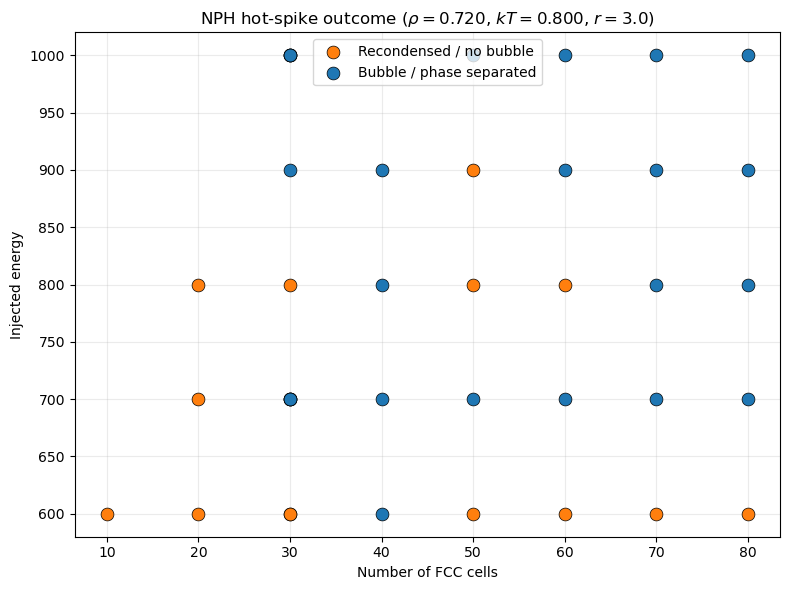

In [1]:
import matplotlib.pyplot as plt

from md_Helpers import master_csv


densities = [0.720]
temperatures = [0.800]
energies = [600, 650, 700, 750, 800, 850, 900, 950, 1000]

radii = [3.0]
n_cells = [10, 20, 30, 40, 50, 60, 70, 80]


df = master_csv.build_excitation_evolved_master_csv(include_legacy=False)

sweep = df[
    df["n_fcc_cells"].isin(n_cells)
    & df["energy_deposition"].isin(energies)
    & df["density"].isin(densities)
    & df["temp"].isin(temperatures)
    & df["radius"].isin(radii)
    & (df["excitation_method"] == "velocity_rescale_com")
    & (df["ensemble"].str.upper() == "NPH")
].copy()


# Start with the final voxel result for completed simulations.
sweep["plot_phase"] = sweep["voxel_phase"]

# New runs record an upper-volume stop explicitly as a terminal bubble.
recorded_bubble_stop = sweep["outcome"].eq("bubble")

# Compatibility for runs created before terminal outcomes were recorded.
legacy_upper_limit_stop = (
    sweep["outcome"].fillna("").eq("")
    & ~sweep["files_complete"].fillna(False).astype(bool)
    & (sweep["voxel_phase"] == "not_classified")
    & sweep["status"].isin(["running", "segment_1_complete"])
)
upper_limit_stop = recorded_bubble_stop | legacy_upper_limit_stop

sweep.loc[upper_limit_stop, "plot_phase"] = "phase_separated"
sweep.loc[legacy_upper_limit_stop, "outcome_source"] = (
    "legacy_inferred_upper_volume_safety_stop"
)

completed = ~upper_limit_stop
sweep.loc[completed, "outcome_source"] = (
    "final_voxel_classification"
)


colors = {
    "phase_separated": "tab:blue",
    "not_phase_separated": "tab:orange",
}

labels = {
    "phase_separated": "Bubble / phase separated",
    "not_phase_separated": "Recondensed / no bubble",
}

fig, ax = plt.subplots(figsize=(8, 6))

for phase, group in sweep.groupby("plot_phase"):
    if phase not in colors:
        continue

    ax.scatter(
        group["n_fcc_cells"],
        group["energy_deposition"],
        s=85,
        color=colors[phase],
        label=labels[phase],
        edgecolor="black",
        linewidth=0.5,
        zorder=3,
    )

ax.set(
    xlabel="Number of FCC cells",
    ylabel="Injected energy",
    title=r"NPH hot-spike outcome "
          r"($\rho=0.720$, $kT=0.800$, $r=3.0$)",
)

ax.set_xticks(n_cells)
ax.set_yticks(energies)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

Wrote 688 excitation evolution rows:
/exp/e961/data/MDsims-data/pnichols/Master_CSVs_v3/excitation_evolved_master.csv
/home/pnichols/MDsims/excitation_evolved_master.csv


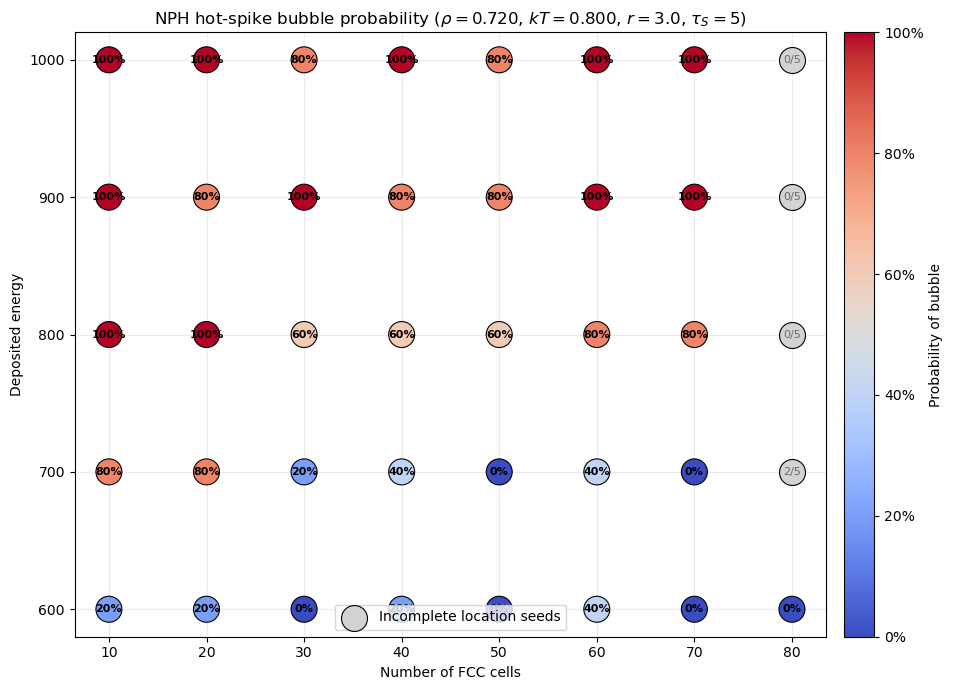

,n_fcc_cells,energy_deposition,n_finished,n_expected,bubble_count,all_finished,bubble_probability
0,10,600,5,5,1,True,0.2
1,10,700,5,5,4,True,0.8
2,10,800,5,5,5,True,1.0
3,10,900,5,5,5,True,1.0
4,10,1000,5,5,5,True,1.0
5,20,600,5,5,1,True,0.2
6,20,700,5,5,4,True,0.8
7,20,800,5,5,5,True,1.0
8,20,900,5,5,4,True,0.8
9,20,1000,5,5,5,True,1.0


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from matplotlib.ticker import PercentFormatter
from md_Helpers import master_csv


# ============================================================
# Sweep definition
# ============================================================

densities = [0.720]
temperatures = [0.800]
energies = [600, 700, 800, 900, 1000]

radii = [3.0]
n_cells = [10, 20, 30, 40, 50, 60, 70, 80]
location_seeds = [1, 2, 3, 4, 5]

source_nsteps = 1_000_000
source_seed = 1
evolve_seed = 1

excitation_method = "velocity_rescale_com"

# Two-segment evolution settings
dt1 = 0.0005
nsteps1 = 200_000

dt2 = 0.005
nsteps2 = 80_000

# NPH settings
tauS = 5.0
pressure_couple = "xyz"
barostat_gamma = 0.0

outer_mask_diameter_fraction = 0.75
nph_mask_controls_box = False


# ============================================================
# Load the NVE and NPH master database
# ============================================================

df = master_csv.build_excitation_evolved_master_csv(
    include_legacy=False,
)


# ============================================================
# Select this specific NPH sweep
# ============================================================

run_paths = df["run_path"].fillna("")

sweep = df[
    df["n_fcc_cells"].isin(n_cells)
    & df["energy_deposition"].isin(energies)
    & np.isclose(df["density"], densities[0])
    & np.isclose(df["temp"], temperatures[0])
    & np.isclose(df["radius"], radii[0])
    & df["excitation_method"].eq(excitation_method)
    & df["ensemble"].fillna("").str.upper().eq("NPH")
    & df["source_nsteps"].eq(source_nsteps)
    & df["source_seed"].eq(source_seed)
    & df["evolve_seed"].eq(evolve_seed)
    & df["nsteps1"].eq(nsteps1)
    & np.isclose(df["dt1"], dt1)
    & df["nsteps2"].eq(nsteps2)
    & np.isclose(df["dt2"], dt2)
    & np.isclose(df["tauS"], tauS)
    & run_paths.str.contains(
        (
            f"/couple_{pressure_couple}/"
            f"gamma_{barostat_gamma:.3f}/"
        ),
        regex=False,
    )
    & run_paths.str.contains(
        (
            "/outer_mask_diameter_"
            f"{outer_mask_diameter_fraction:.3f}L/"
        ),
        regex=False,
    )
    & run_paths.str.contains(
        (
            "/pressure_control_outer_mask_experimental/"
            if nph_mask_controls_box
            else "/pressure_control_all_particles/"
        ),
        regex=False,
    )
].copy()


# ============================================================
# Recover the independent location seed from each run path
# ============================================================

sweep["location_seed"] = pd.to_numeric(
    sweep["run_path"].str.extract(
        r"random_center_seed_(\d+)",
        expand=False,
    ),
    errors="coerce",
)

sweep = sweep[
    sweep["location_seed"].isin(location_seeds)
].copy()

sweep["location_seed"] = sweep["location_seed"].astype(int)


# Keep only the newest database entry for each configuration.
sweep = (
    sweep.sort_values("last_updated")
    .drop_duplicates(
        [
            "n_fcc_cells",
            "energy_deposition",
            "location_seed",
        ],
        keep="last",
    )
)


# ============================================================
# Determine which NPH runs are complete
# ============================================================

# Ordinary completion requires all expected output files.
normal_finish = (
    sweep["files_complete"]
    .fillna(False)
    .eq(True)
)

# An NPH upper-volume safety stop recorded as a terminal bubble
# is also a completed and classified result.
terminal_bubble = (
    sweep["terminal"].fillna(False).eq(True)
    & sweep["outcome"].fillna("").eq("bubble")
)

sweep["finished"] = normal_finish | terminal_bubble

# A finished run is classified as a bubble when either the
# terminal outcome or final voxel classification indicates one.
sweep["bubble"] = (
    sweep["outcome"].fillna("").eq("bubble")
    | sweep["voxel_phase"]
        .fillna("")
        .eq("phase_separated")
)


# ============================================================
# Build the complete cell-size × energy grid
# ============================================================

expected_seeds = set(location_seeds)
records = []

for n_cell in n_cells:
    for energy in energies:
        point = sweep[
            sweep["n_fcc_cells"].eq(n_cell)
            & sweep["energy_deposition"].eq(energy)
        ]

        finished = point[point["finished"]]
        finished_seeds = set(finished["location_seed"])

        n_finished = len(
            expected_seeds.intersection(finished_seeds)
        )
        all_finished = expected_seeds.issubset(
            finished_seeds
        )

        bubble_count = int(
            finished["bubble"].sum()
        )

        bubble_probability = (
            float(finished["bubble"].mean())
            if all_finished
            else np.nan
        )

        records.append(
            {
                "n_fcc_cells": n_cell,
                "energy_deposition": energy,
                "n_finished": n_finished,
                "n_expected": len(location_seeds),
                "bubble_count": bubble_count,
                "all_finished": all_finished,
                "bubble_probability": bubble_probability,
            }
        )

summary = pd.DataFrame(records)


# ============================================================
# Plot NPH bubble probability
# ============================================================

complete = summary[summary["all_finished"]]
incomplete = summary[~summary["all_finished"]]

fig, ax = plt.subplots(figsize=(10, 7))

probability_points = ax.scatter(
    complete["n_fcc_cells"],
    complete["energy_deposition"],
    c=complete["bubble_probability"],
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    s=350,
    edgecolor="black",
    linewidth=0.8,
    zorder=3,
)

ax.scatter(
    incomplete["n_fcc_cells"],
    incomplete["energy_deposition"],
    color="lightgray",
    s=350,
    edgecolor="black",
    linewidth=0.8,
    label="Incomplete location seeds",
    zorder=3,
)


# Complete points show bubble probability.
for row in complete.itertuples():
    ax.annotate(
        f"{row.bubble_probability:.0%}",
        (
            row.n_fcc_cells,
            row.energy_deposition,
        ),
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
    )


# Incomplete points show completed/expected seeds.
for row in incomplete.itertuples():
    ax.annotate(
        f"{row.n_finished}/{row.n_expected}",
        (
            row.n_fcc_cells,
            row.energy_deposition,
        ),
        ha="center",
        va="center",
        fontsize=8,
        color="dimgray",
    )


colorbar = fig.colorbar(
    probability_points,
    ax=ax,
    pad=0.02,
)
colorbar.set_label("Probability of bubble")
colorbar.ax.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

ax.set(
    xlabel="Number of FCC cells",
    ylabel="Deposited energy",
    title=(
        "NPH hot-spike bubble probability "
        f"($\\rho={densities[0]:.3f}$, "
        f"$kT={temperatures[0]:.3f}$, "
        f"$r={radii[0]:.1f}$, "
        f"$\\tau_S={tauS:g}$)"
    ),
)

ax.set_xticks(n_cells)
ax.set_yticks(energies)
ax.grid(alpha=0.25)
ax.legend(loc="best")

fig.tight_layout()
plt.show()


# ============================================================
# Display tabular results
# ============================================================

display(
    summary.sort_values(
        [
            "n_fcc_cells",
            "energy_deposition",
        ]
    ).reset_index(drop=True)
)